In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/deals_transformados.csv"
)

df.head()

,titulo,precio_oferta,precio_normal,ahorro_porcentaje,store_id,rating_steam,steam_rating_count,metacritic,deal_rating,steam_app_id,release_date,fecha_extraccion,ahorro_real,precio_relacion,categoria_descuento,popularidad,descuento_calidad,tipo_precio,antiguedad_dias,antiguedad_anios
0,Valdis Story Abyssal City,14.99,14.99,0.00,2,82.0,1648,83.0,0.0,252030.0,2013-09-08,2026-05-13 20:22:13.538415,0.00,1.00,NaN,Bueno,0.00,Normal,4630,12.7
1,Mr. Robot,14.99,14.99,0.00,2,82.0,95,83.0,0.0,20710.0,2007-01-10,2026-05-13 20:22:13.538410,0.00,1.00,NaN,Bueno,0.00,Normal,7063,19.4
2,Independence War 2 - Edge of Chaos,5.99,5.99,0.00,2,75.0,88,83.0,0.0,359630.0,2001-08-22,2026-05-13 20:22:13.538404,0.00,1.00,NaN,Bueno,0.00,Barato,9030,24.7
3,Kumitantei: Old-School Slaughter,14.99,14.99,0.00,2,89.0,222,84.0,0.0,2759280.0,2026-04-23,2026-05-13 20:22:13.538383,0.00,1.00,NaN,Excelente,0.00,Normal,20,0.1
4,News Tower,18.74,24.99,25.01,2,94.0,2677,84.0,4.6,1649950.0,2025-11-18,2026-05-13 20:22:13.538376,6.25,0.75,Medio,Excelente,2350.94,Normal,176,0.5


In [3]:
df.head()

df["es_oferta_brutal"] = np.where(
    df["ahorro_porcentaje"] >= 80,
    1,
    0
)

df["es_oferta_brutal"].value_counts()

es_oferta_brutal
0    382
1    250
Name: count, dtype: int64

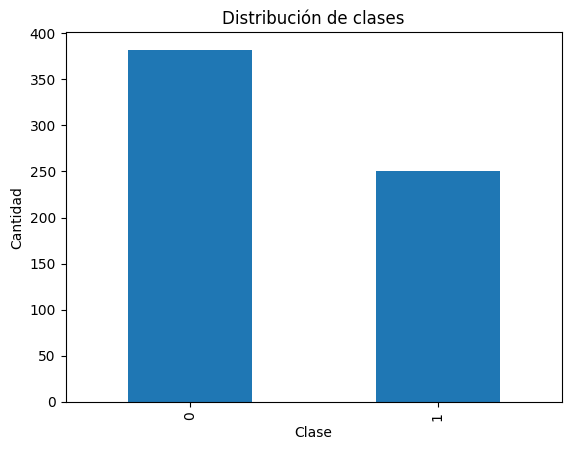

In [4]:
import matplotlib.pyplot as plt

df["es_oferta_brutal"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [5]:
features = [

    "precio_oferta",
    "precio_normal",
    "rating_steam",
    "metacritic",
    "deal_rating",
    "steam_rating_count",
    "antiguedad_anios"

]

X = df[features]

y = df["es_oferta_brutal"]

In [6]:
X = X.fillna(X.mean())


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
splits = {

    "80_20": 0.20,
    "70_30": 0.30,
    "60_40": 0.40

}

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

resultados = []

In [10]:
for nombre, test_size in splits.items():

    print("\n")
    print("=" * 60)
    print(f"SPLIT {nombre}")
    print("=" * 60)

    # -----------------------------------
    # SPLIT
    # -----------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X_scaled,
        y,

        test_size=test_size,

        random_state=42,

        stratify=y

    )

    # -----------------------------------
    # MODELO
    # -----------------------------------

    modelo = LogisticRegression(

        class_weight="balanced",
        random_state=42,
        max_iter=1000

    )

    modelo.fit(X_train, y_train)

    # -----------------------------------
    # PREDICCIONES
    # -----------------------------------

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]

    # -----------------------------------
    # MÉTRICAS
    # -----------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    # -----------------------------------
    # RESULTADOS
    # -----------------------------------

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1-Score : {f1:.4f}")

    print(f"ROC AUC  : {auc:.4f}")

    resultados.append({

        "split": nombre,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc

    })

    # -----------------------------------
    # MATRIZ CONFUSIÓN
    # -----------------------------------

    cm = confusion_matrix(y_test, y_pred)

    print("\nMatriz de confusión:\n")

    print(cm)

    # -----------------------------------
    # REPORTE
    # -----------------------------------

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )



SPLIT 80_20
Accuracy : 0.8346
Precision: 0.7042
Recall   : 1.0000
F1-Score : 0.8264
ROC AUC  : 0.9777

Matriz de confusión:

[[56 21]
 [ 0 50]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.73      0.84        77
           1       0.70      1.00      0.83        50

    accuracy                           0.83       127
   macro avg       0.85      0.86      0.83       127
weighted avg       0.88      0.83      0.84       127



SPLIT 70_30
Accuracy : 0.8526
Precision: 0.7327
Recall   : 0.9867
F1-Score : 0.8409
ROC AUC  : 0.9724

Matriz de confusión:

[[88 27]
 [ 1 74]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.77      0.86       115
           1       0.73      0.99      0.84        75

    accuracy                           0.85       190
   macro avg       0.86      0.88      0.85       190
weighted avg       0.89      0.85      0.85       190



SP

In [11]:
resultados_df = pd.DataFrame(resultados)

resultados_df

,split,accuracy,precision,recall,f1,auc
0,80_20,0.834646,0.704225,1.000000,0.826446,0.977662
1,70_30,0.852632,0.732673,0.986667,0.840909,0.972406
2,60_40,0.861660,0.744361,0.990000,0.849785,0.972745


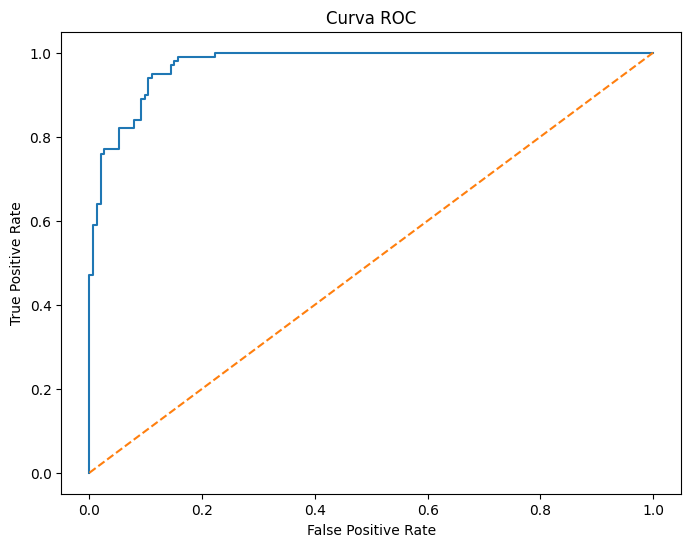

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.show()

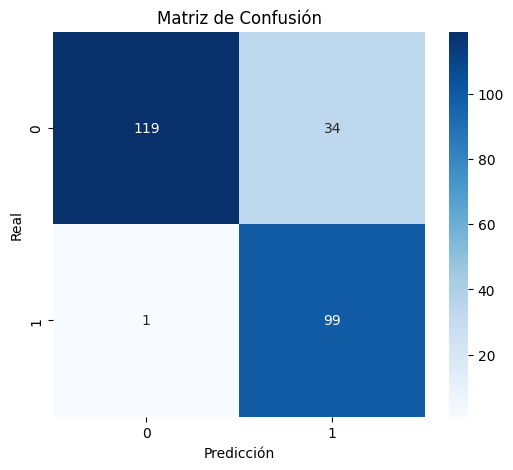

In [13]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,
    fmt="d",
    cmap="Blues"

)

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.title("Matriz de Confusión")

plt.show()

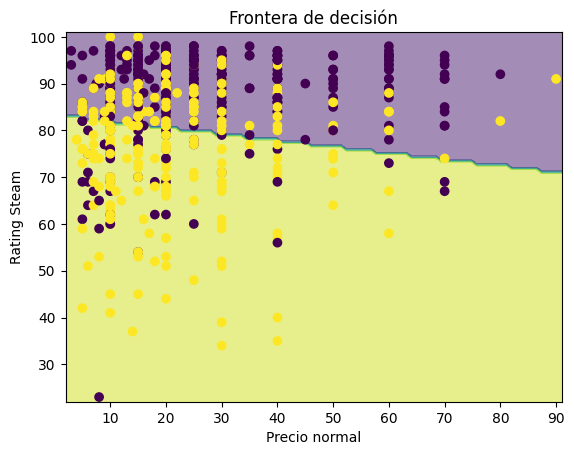

In [14]:
X_2d = df[[
    "precio_normal",
    "rating_steam"
]]

y_2d = df["es_oferta_brutal"]

from sklearn.inspection import DecisionBoundaryDisplay

X_train, X_test, y_train, y_test = train_test_split(

    X_2d,
    y_2d,

    test_size=0.2,

    random_state=42

)

modelo_2d = LogisticRegression()

modelo_2d.fit(X_train, y_train)

DecisionBoundaryDisplay.from_estimator(

    modelo_2d,
    X_2d,
    response_method="predict",

    alpha=0.5

)

plt.scatter(

    X_2d.iloc[:,0],
    X_2d.iloc[:,1],

    c=y_2d

)

plt.xlabel("Precio normal")

plt.ylabel("Rating Steam")

plt.title("Frontera de decisión")

plt.show()